In [2]:
import os
print(os.getcwd())


/Users/raafaysiddiqui/Desktop/covid19_xray_classifier


In [4]:
import os

base_dir = "dataset/Coronahack-Chest-XRay-Dataset"
print("Train classes:", os.listdir(os.path.join(base_dir, "train")))


Train classes: ['person63_bacteria_306.jpeg', 'person1438_bacteria_3721.jpeg', 'person755_bacteria_2659.jpeg', 'person478_virus_975.jpeg', 'NORMAL2-IM-0927-0001.jpeg', 'person661_bacteria_2553.jpeg', 'person276_bacteria_1296.jpeg', 'person1214_bacteria_3166.jpeg', 'person1353_virus_2333.jpeg', 'person26_bacteria_122.jpeg', 'person124_virus_238.jpeg', 'person1619_bacteria_4261.jpeg', 'person890_bacteria_2814.jpeg', 'person1514_bacteria_3964.jpeg', 'NORMAL2-IM-1056-0001.jpeg', 'IM-0427-0001.jpeg', 'person1491_bacteria_3893.jpeg', 'person69_bacteria_338.jpeg', 'NORMAL2-IM-1260-0001.jpeg', 'person321_bacteria_1489.jpeg', 'person281_bacteria_1329.jpeg', 'person688_bacteria_2584.jpeg', 'person1598_bacteria_4197.jpeg', 'person535_virus_1062.jpeg', 'IM-0656-0001-0001.jpeg', 'IM-0561-0001.jpeg', 'person1222_bacteria_3177.jpeg', 'person581_bacteria_2392.jpeg', 'NORMAL2-IM-1110-0001.jpeg', 'person1233_virus_2090.jpeg', 'person1816_bacteria_4674.jpeg', 'person1812_bacteria_4667.jpeg', 'IM-0757-000

In [6]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [8]:
base_dir = "dataset/Coronahack-Chest-XRay-Dataset"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")



img_size = 224
batch_size = 32


In [10]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.


In [12]:
import os
import shutil

# Paths
train_dir = "dataset/Coronahack-Chest-XRay-Dataset/train"
test_dir = "dataset/Coronahack-Chest-XRay-Dataset/test"

def organize_images(base_dir):
    normal_dir = os.path.join(base_dir, "NORMAL")
    pneumonia_dir = os.path.join(base_dir, "PNEUMONIA")
    
    # Create folders if they don't exist
    os.makedirs(normal_dir, exist_ok=True)
    os.makedirs(pneumonia_dir, exist_ok=True)
    
    for filename in os.listdir(base_dir):
        if filename.endswith(".jpeg") or filename.endswith(".jpg"):
            src = os.path.join(base_dir, filename)
            if "NORMAL" in filename.upper():
                shutil.move(src, os.path.join(normal_dir, filename))
            else:
                shutil.move(src, os.path.join(pneumonia_dir, filename))

# Organize both train and test sets
organize_images(train_dir)
organize_images(test_dir)

print("✅ Images have been sorted into NORMAL and PNEUMONIA folders!")


✅ Images have been sorted into NORMAL and PNEUMONIA folders!


In [14]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)


Found 4242 images belonging to 2 classes.


In [16]:
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 1059 images belonging to 2 classes.


In [18]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary output: 0 or 1
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 20  

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs
)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 98s 729ms/step - accuracy: 0.8473 - loss: 0.3860 - val_accuracy: 0.7554 - val_loss: 0.4382
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 108s 811ms/step - accuracy: 0.9417 - loss: 0.1510 - val_accuracy: 0.5543 - val_loss: 0.6466
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 125s 939ms/step - accuracy: 0.9589 - loss: 0.1064 - val_accuracy: 0.4806 - val_loss: 1.0841
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 102s 767ms/step - accuracy: 0.9709 - loss: 0.0905 - val_accuracy: 0.4967 - val_loss: 0.9380
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 109s 816ms/step - accuracy: 0.9681 - loss: 0.0885 - val_accuracy: 0.5156 - val_loss: 1.1341
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 109s 816ms/step - accuracy: 0.9674 - loss: 0.0851 - val_accuracy: 0.5099 - val_loss: 1.0684
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 101s 761ms/step - accuracy: 0.9740 - loss: 0.0694 - val_accuracy: 0.4674 - val_loss: 1.4374
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 100s 747ms/step - accuracy: 0.9765 - 

In [4]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'history' is not defined

In [6]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)



NameError: name 'model' is not defined

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


NameError: name 'train_gen' is not defined

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32
train_dir = "dataset/Coronahack-Chest-XRay-Dataset/train"

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 4242 images belonging to 2 classes.
Found 1059 images belonging to 2 classes.


In [14]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 87s 646ms/step - accuracy: 0.8421 - loss: 0.3930 - val_accuracy: 0.5449 - val_loss: 0.6753
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 85s 639ms/step - accuracy: 0.9459 - loss: 0.1426 - val_accuracy: 0.5165 - val_loss: 0.8300
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 88s 661ms/step - accuracy: 0.9525 - loss: 0.1118 - val_accuracy: 0.4882 - val_loss: 1.0927
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 88s 660ms/step - accuracy: 0.9665 - loss: 0.0903 - val_accuracy: 0.4693 - val_loss: 1.0564
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 92s 690ms/step - accuracy: 0.9709 - loss: 0.0801 - val_accuracy: 0.4750 - val_loss: 1.1732
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 90s 673ms/step - accuracy: 0.9739 - loss: 0.0726 - val_accuracy: 0.4523 - val_loss: 1.2650
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 93s 695ms/step - accuracy: 0.9780 - loss: 0.0650 - val_accuracy: 0.4589 - val_loss: 1.7730
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 92s 692ms/step - accuracy: 0.9712 - loss: 0

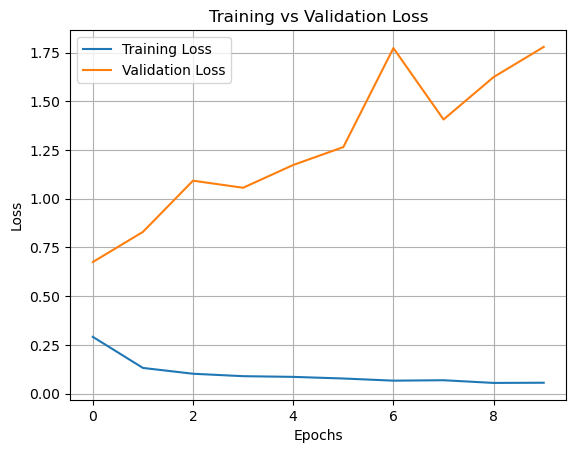

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
test_dir = "dataset/Coronahack-Chest-XRay-Dataset/test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

loss, accuracy = model.evaluate(test_gen)
print(f"🧪 Test Loss: {loss:.4f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")


Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.6041 - loss: 2.2233
🧪 Test Loss: 1.1527
✅ Test Accuracy: 0.7869


In [20]:
model.save("covid_xray_cnn_model.h5")
print("✅ Model saved as covid_xray_cnn_model.h5")

✅ Model saved as covid_xray_cnn_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step
Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.34      0.46       165
   Pneumonia       0.80      0.95      0.87       459

    accuracy                           0.79       624
   macro avg       0.75      0.64      0.66       624
weighted avg       0.77      0.79      0.76       624



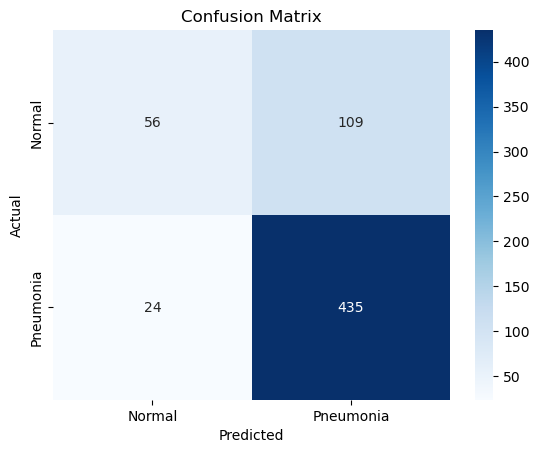

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predicted labels
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [25]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

#function to generate Grad-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_2"):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# pick one image from the test set
img_path = test_gen.filepaths[0]  # pick first test image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.

#generate heatmap
heatmap = make_gradcam_heatmap(img_array, model)

#display Grad-CAM
plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.4)  # heatmap overlay
plt.title("Grad-CAM: Focused Regions for Prediction")
plt.axis('off')
plt.show()


AttributeError: The layer sequential has never been called and thus has no defined output.

In [27]:
_ = model.predict(np.zeros((1, 224, 224, 3)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


In [29]:
grad_model = Model(
    inputs=[model.inputs],
    outputs=[model.get_layer("conv2d_2").output, model.output]
)

NameError: name 'Model' is not defined

In [31]:
from tensorflow.keras.models import Model


In [33]:
import numpy as np


In [35]:
from tensorflow.keras.models import Model

_ = model.predict(np.zeros((1, 224, 224, 3)))

grad_model = Model(
    inputs=[model.inputs],
    outputs=[model.get_layer("conv2d_2").output, model.output]
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


AttributeError: The layer sequential has never been called and thus has no defined output.

In [37]:
from tensorflow.keras.models import Model

_ = model.predict(np.zeros((1, 224, 224, 3)))

grad_model = Model(
    inputs=[model.inputs],
    outputs=[model.get_layer("conv2d_2").output, model.output]
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


AttributeError: The layer sequential has never been called and thus has no defined output.